[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/porterjenkins/byu-cs474/blob/master/lab7_style_transfer.ipynb)

# Style Transfer



In this lab, you will implement the style transfer algorithm proposed by [Gatys et. al. (2015)](https://arxiv.org/pdf/1508.06576.pdf). Your goal is to produce an image that has the high-level content of one image and the low-level style of another.

To perform style transfer, we will use a neural network as a feature extractor to determine style and content features, and we will optimize an image to reach a balance of the chosen style and content. Note that the network does not generate the final image, nor is the network trained at any point in this lab; instead of training network weights, we train the image itself. Through this lab, you will experience another way to use neural networks and see how deep learning can be used to optimize structures other than neural networks.



---

## Grading standards

Your code will be graded on the following:

* 20% Correct extraction of image statistics
* 35% Correct construction of loss function in a loss class
* 20% Plain English description of equations from (Gatys et. al. 2015) at the bottom of the notebook
* 15% Correct initialization and optimization of image variable
* 10% Awesome looking final image

---

Here's an additional example of style transfer:

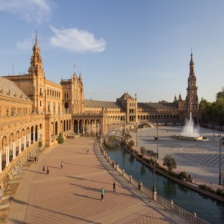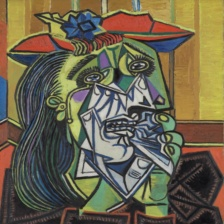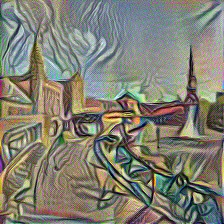

---

## Lab Setup

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from tqdm import tqdm
from torch.nn.parameter import Parameter
from PIL import Image
import io

# IF NOT USING COLAB: comment out the following import statement:
from google.colab import files

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Select two images: one for content and one for style. The images should have noticeably different content and style from each other to make it clear if the style transfer worked.

In [16]:
# Use this code to upload your own images.
# NOTE: if you are not using Colab, `upload()` will not work. Just make sure the images are on your file system and set `content_path` and `style_path` accordingly.

load_and_normalize = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

def upload():
  print('Upload Content Image')
  file_dict = files.upload()
  content_path = io.BytesIO(file_dict[next(iter(file_dict))])

  print('\nUpload Style Image')
  file_dict = files.upload()
  style_path = io.BytesIO(file_dict[next(iter(file_dict))])
  return content_path, style_path

content_path, style_path = upload()

print("Content Path: {}".format(content_path))
print("Style Path: {}".format(style_path))


Upload Content Image


Saving lewis-hamilton-ferrari.webp to lewis-hamilton-ferrari (1).webp

Upload Style Image


Saving the-starry-night.webp to the-starry-night.webp
Content Path: <_io.BytesIO object at 0x7d3c8474f6f0>
Style Path: <_io.BytesIO object at 0x7d3c846567f0>


In [17]:
# Load in and normalize the images
content_image_orig = Image.open(content_path)
content_image = load_and_normalize(content_image_orig).unsqueeze(0).to(device)
style_image_orig = Image.open(style_path)
style_image = load_and_normalize(style_image_orig).unsqueeze(0).to(device)


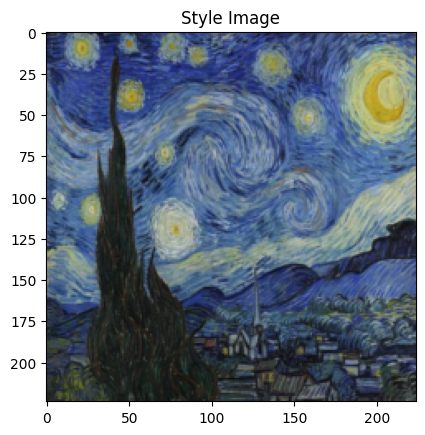

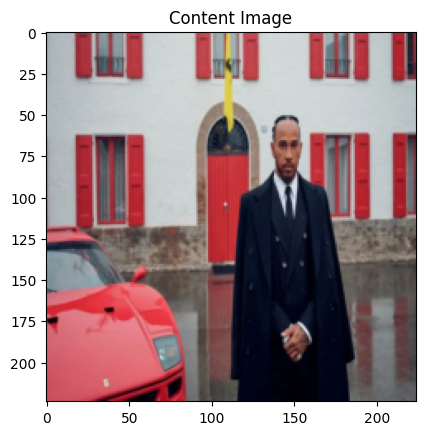

In [18]:
# Display the images
toPIL = transforms.ToPILImage()

def display(tensor, title=None):
    image = tensor.cpu().clone()
    image = image.squeeze(0)
    image = toPIL(image)
    plt.imshow(image)
    if title is not None:
        plt.title(title)
    plt.show()

plt.figure()
display(style_image, title='Style Image')

plt.figure()
display(content_image, title='Content Image')


___

## Part 1


We will use a pretrained VGG-16 network as a feature extractor to get the style and content statistics from the images.

We provide you with the `VGGIntermediate` class to load in the pretrained model and to grab intermediate layers.



* Correctly initialize a VGGIntermediate object to extract style and content
* Gather content statistics from the outputs of intermediate layers for the content image
* Gather style statistics for the style image

In [19]:
import torchvision.models as models

# You should not have to change any of the code in the following classes.

# Normalization layer normalizes the image pixels to mean=0 std=1 according to the statistics of the ImageNet training dataset (which the VGG was pretrained on)
class Normalization(nn.Module):
  def __init__(self):
      super(Normalization, self).__init__()
      self.mean = torch.tensor([0.485, 0.456, 0.406]).view(-1, 1, 1).to(device)
      self.std = torch.tensor([0.229, 0.224, 0.225]).view(-1, 1, 1).to(device)

  def forward(self, img):
      return (img - self.mean) / self.std

# Wrapper for the pretrained VGG-16. Instead of returning the output of the VGG, it returns the `requested` layers.
class VGGIntermediate(nn.Module):
  def __init__(self, requested=[]):
    super(VGGIntermediate, self).__init__()
    self.norm = Normalization().eval()
    self.intermediates = {}
    self.vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1).features.eval()
    for i, m in enumerate(self.vgg.children()):
        if isinstance(m, nn.ReLU):   # we want to set the relu layers to NOT do the relu in place.
          m.inplace = False          # the model has a hard time going backwards on the in place functions.

        if i in requested:
          # This stores the output of the requested layer as `intermediates[i]`
          def curry(i):
            def hook(module, input, output):
              self.intermediates[i] = output
            return hook
          m.register_forward_hook(curry(i))

  def forward(self, x):
    self.vgg(self.norm(x))
    return self.intermediates.copy()

We provide you with the list of VGG-16 layer names. Select the names of the layers you'd like to use to extract the content and style ([Gatys et. al. (2016)](https://arxiv.org/pdf/1508.06576.pdf) has suggestions on which layers to use on pages 3 and 12).

Save the layer indexes (not names) into a list for the `requested` parameter of `VGGIntermediate`.

In [20]:
vgg_names = ["conv1_1", "relu1_1", "conv1_2", "relu1_2", "maxpool1", "conv2_1", "relu2_1", "conv2_2", "relu2_2", "maxpool2", "conv3_1", "relu3_1", "conv3_2", "relu3_2", "conv3_3", "relu3_3","maxpool3", "conv4_1", "relu4_1", "conv4_2", "relu4_2", "conv4_3", "relu4_3","maxpool4", "conv5_1", "relu5_1", "conv5_2", "relu5_2", "conv5_3", "relu5_3","maxpool5"]

In [21]:
style_layers = [0,5,10,17,24]
content_layers = [19]

Create a `VGGIntermediate` object, providing it with the intermediate layers. You can use a single network to extract both the content and the style, but be sure to keep track of which layers are which.

In [22]:
requested_layers = style_layers + content_layers
vgg = VGGIntermediate(requested_layers).to(device)

Use your `VGGIntermediate` network to extract the content from `content_image` and the style from `style_image`. Save these tensors: they will be used throughout training! Be sure to detach these tensors, since these are our labels and we don't want to backpropagate with respect to them.

In [23]:
with torch.no_grad():
  content_outputs = vgg(content_image)
  style_outputs = vgg(style_image)

content_targets = {
    idx: content_outputs[idx].detach()
    for idx in content_layers
}

style_targets = {
    idx: style_outputs[idx].detach()
    for idx in style_layers
}

---

## Part 2



The loss functions are key to learning the correct behavior in any machine learning problem. For style transfer, we have two losses: content loss and style loss. Our final loss is a combination of both to provide a balance between these competing objectives.

Show that you understand style transfer by describing the key equations of [Gatys et al. 2016](https://arxiv.org/pdf/1508.06576.pdf) in your own words. You may need to read the surrounding sections to understand the equations.

Content Loss:

- Describe equation (1) on p. 10 of (Gatys 2016) in plain English. Include the meaning of all variables and what each dimension represents for each matrix and vector variable.

$\mathcal{L}_{content}(\vec{p}, \vec{x}, l) = \frac{1}{2}\sum_{i,j} (F^l_{ij} - P^l_{ij})^2$

**Answer for content loss:** It measures how much the generated image differs from our original content image at a certain layer of the neural network. This equation is the squared error loss between the two images.

For each variable:

- $\mathcal{L}_{content}$ is the total loss content for a specific layer
- $\mathcal(\vec{p}, \vec{x}, l)$ `p` is the original image, `x` is the generated image, and `l` is the specific layer of the VGG network being used
- $\mathcal F^l_{ij}$ is the activation of the `ith` filter at position `j` in specifically layer `l`. Represents our generated image layer.
- $\mathcal P^l_{ij}$ same thing as the variable right above this, except it represents our original image at that layer.

Dimensions:
As mentioned, i represents the filter index, or our row. j represents the position at that filter. p and x, our vector variables, are our image representations flattened into a single vector.

Style Loss:

- Describe equation (3) on p. 11 of (Gatys 2016) in plain English, including the meaning of all variables and what each dimension represents for each matrix and vector variable (including the output).

$G^l_{ij} = \sum_k F^l_{ik} F^l_{jk}$

**Answer for equation 3:** This equation is what we call the Gram Matrix. This basically measures style correlations in a specific layer between features in that layer.

For each variable:
- $G^l_{ij}$ Our gram matrix for layer `l` at row i and column `j`. The inner product of our feature map at that specific position.
- $F^l_{ik}$ Activation at the `ith` filter at position/column `k` in layer `l`
- $F^l_{jk}$ Activation at the `jth` filter at position/column `k` in layer `l`
- $\sum_k$ This equation sums over all positions `k`

Dimensions:
For the inputs $F^l$, `i and j` represent the filter index, while `k` represents the specific position at a particular filter.

For the output, $G^l_{ij}$, this is a square matrix and as we mentioned is the inner product of filter maps `i and j` across all positions and represents the relationship of style between them.


- Describe equation (4) on p. 11 of (Gatys 2016) in plain English, including the meaning of all variables and what each dimension represents for each matrix and vector variable.

$E_l = \frac{1}{4N_l^2M_l^2} \sum_{i,j} (G^l_{ij} - A^l_{ij})^2$

**Answer for equation 4:** This equation is the mean squared difference between two different gram matrixes. So it calculates the differences between the generated image style and the target image style.

For each variable:
- $E_l$ Style loss for particular layer `l`
- $G^l_{ij}$ Gram matrix for our generated image at layer `l`
- $A^l_{ij}$ Gram matrix for our target/original style image at layer `l`
- $N_l$ Number of filters in layer `l`
- $M_l$ spatial size of feature map in layer `l`
- $\sum_{i,j}$ Sum over all rows and columns of each of the gram matrices

Dimensions:
For $G^l$ and $A^l$ since these are gram matrices, they are sqaure matrices $N_l * N_l$

For the variables, $N_l$ and $M_l$ these are just scalar values to help us normalize. $N_l$ represents the count of filters at a layer and $M_l$ represents the total number of pixels of a feature map (or size of feature map in the layer)


- Describe equation (5) on p. 11 of (Gatys 2016) in plain English, including the meaning of all variables and subscripts.

$\mathcal{L}_{style}(\vec{a}, \vec{x}) = \sum^L_{l=0} w_lE_l$

**Answer for equation 5:** From the previous equation, we calculated total loss on a single layer. Now this equation calculates total loss over all the layers. It combines all the styling information from all layers to capture the style of the specific style image.

For each variable:
- ${L}_{style}$ is the total style loss for the entire image
- $\vec{a}$ is the original style image
- $\vec{x}$ the generated image
- $l$ index of a specific layer
- $L$ Total number of layers we will sum over
- $w_l$ Weighting factor of the contribution of each layer to our total loss
- $E_l$ style loss for a specific layer

Dimensions:
For the variables `a and x`, these are vectors that represent the images, usually dimensions 3 * H * W. $w_l$ is a just a number. $E_l$ is also a scalar value, and $L_{style}$ is also a scalar value

___

## Part 3


Now that you understand the loss functions mathematically, create modules that calculate the content and style loss for a single content or style layer.

Since the targets will be static throughout learning (the content and style images don't change, nor the network), we can store them in the loss module objects, so we don't have to pass them into the forward each time.

In [24]:
# Produces a gram matrix from a 4D tensor input
def gram_matrix(F):
    a, b, c, d = F.size()

    feats = F.view(a * b, c * d)

    G = torch.mm(feats, feats.t())

    return G.div(a * b * c * d)

# Represents the content loss function for a single content layer
class ContentLoss(nn.Module):
  # Since the targets don't change, store the targets in the init
  def __init__(self, target):
      super().__init__()
      self.target = target.detach()
      self.loss = 0

  def forward(self, y_hat):
      self.loss = F.mse_loss(y_hat, self.target)
      return y_hat

# Represents the style loss function for a single style layer
class StyleLoss(nn.Module):
  def __init__(self, target):
      super().__init__()
      self.target = gram_matrix(target).detach()
      self.loss = 0

  def forward(self, y_hat):
      G = gram_matrix(y_hat)
      self.loss = F.mse_loss(G, self.target)
      return y_hat


# Instantiate a content loss module for each content layer
#  with the content reference image outputs for that layer for comparison
content_loss = []
for idx in content_layers:
  target = content_targets[idx]
  content_loss.append(ContentLoss(target))

# Instantiate a style loss module for each style layer
#  with the style reference image outputs for that layer for comparison
style_loss = []
for idx in style_layers:
  target = style_targets[idx]
  style_loss.append(StyleLoss(target))


Now that you have a list of loss modules, write a loss function that computes the combined style transfer loss. You can weight the overall content and style losses, as well as weighting each layerwise loss value.

Return the combined loss as a tensor for learning. Return the content and style loss values for plotting.

In [25]:
alpha = 1
beta = 1e6

style_layer_weights = [1.0/len(style_layers)] * len(style_layers)
content_layer_weights = [1.0/len(content_layers)] * len(content_layers)

def calculate_loss(features, content_loss, style_loss):
  total_content_loss = 0
  total_style_loss = 0

  for i, layer in enumerate(content_layers):
    content_loss[i](features[layer])
    total_content_loss += content_loss[i].loss * content_layer_weights[i]

  for i, layer in enumerate(style_layers):
    style_loss[i](features[layer])
    total_style_loss += style_loss[i].loss * style_layer_weights[i]

  combined = (alpha * total_content_loss) + (beta * total_style_loss)
  return combined,total_content_loss.item(),total_style_loss.item()


___

## Part 4

Create and run a method that minimizes the content and style loss for a copy of the content image

Note that the content loss should be zero if you take out the style loss. Why is that?

**TODO:**

* Use an Adam optimizer (try learning rate of .1, but feel free to experiment)
* Show both the content and the style loss every 50 steps
* Ensure that the outputs don't go out of range (clamp them)
* Display the tensor as an image!
* Experiment with different hyperparameters or network layers until you're satisfied with your final image


First, we need to define our image. While we can create a random image and hope that the optimization works, the best results come from using a clone of the content image. That way, the image starts with the desired content and the content loss only needs to preserve the existing content.

Create a clone of the content image as your initial "generated" image. Calculate and print content and style loss (separately) for your generated image. What do you notice about these losses? Make sure the losses match what you'd expect, given that the generated image is a copy of the content image.

Image range: min=0.0, max=0.9686274528503418


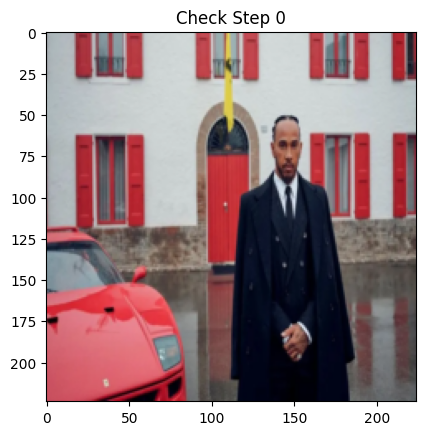

Initial Content Loss: 0.0
Initial Style Loss: 0.018064817413687706


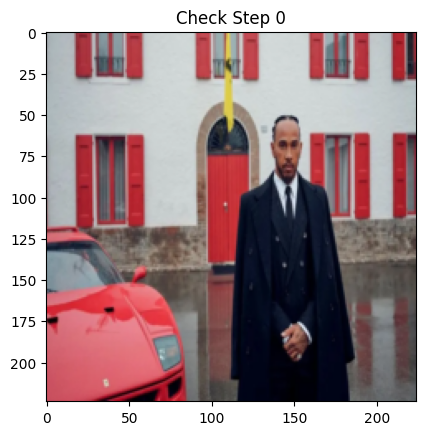

In [26]:
generated_image = content_image.clone().requires_grad_(True).to(device)
print(f"Image range: min={generated_image.min().item()}, max={generated_image.max().item()}")
display(generated_image, title="Check Step 0")

with torch.no_grad():
  features = vgg(generated_image)
  loss, content_loss, style_loss = calculate_loss(features, content_loss, style_loss)

print(f"Initial Content Loss: {content_loss}")
print(f"Initial Style Loss: {style_loss}")
display(generated_image, title="Check Step 0")

Prepare your generated image for optimization. You need two things:


1.   Your generated image must require gradients: set requires_grad to true by setting the object parameter `requires_grad` or calling the function `requires_grad_()`.
2.   Create an optimizer with your generated image as the parameter. Torch optimizers expect a list of parameters (or tensors), so you'll need to wrap your generated image in a single-item list for the optimizer.



In [27]:
# Prepare your generated image to learn
generated_image = content_image.clone().requires_grad_(True).to(device)
# Create your optimizer: we suggest starting using an Adam optimizer with lr=.1
optimizer = optim.Adam([generated_image], lr=.1)

content_loss_modules = []
for idx in content_layers:
    target = content_targets[idx]
    content_loss_modules.append(ContentLoss(target))

style_loss_modules = []
for idx in style_layers:
    target = style_targets[idx]
    style_loss_modules.append(StyleLoss(target))

Now create and run your training loop, storing content and style losses as you train. Remember, you will be optimizing the **generated image** according to the content and style statistics extracted with the network. Print your final image.

For best results, use `torch.clamp_(generated_im.data, 0, 1)` to keep your pixel values in range after each learning step.

Style transfer is very susceptible to overtraining, which introduces a lot of noise to the final image. Print your image often during the training process to find the best-looking image.

Image range: min=0.0, max=0.9686274528503418


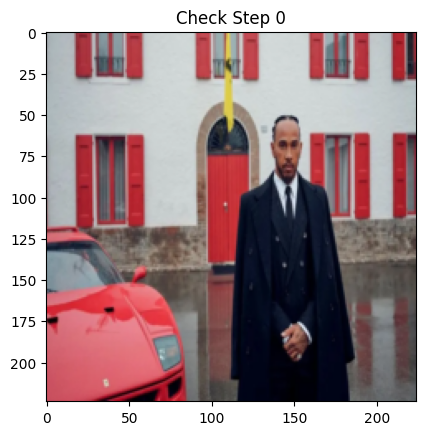

Step 1: Content Loss: 0.0, Style Loss: 0.018064817413687706


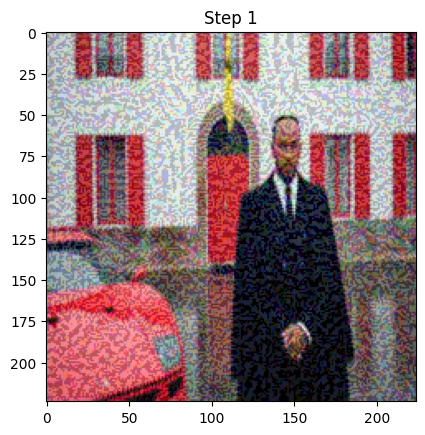

Step 50: Content Loss: 168.1533203125, Style Loss: 0.00024835040676407516


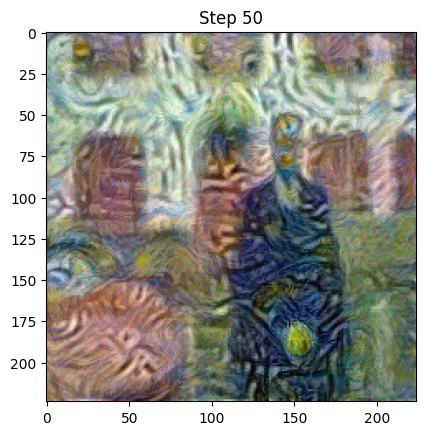

Step 100: Content Loss: 127.42621612548828, Style Loss: 9.64107530307956e-05


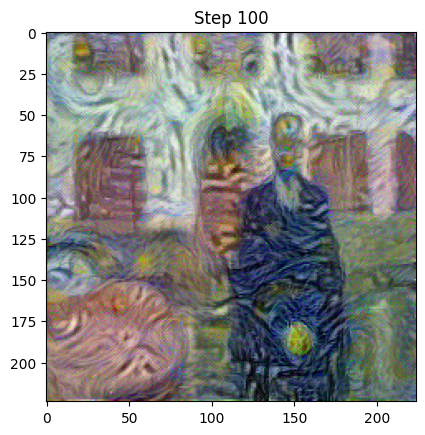

Step 150: Content Loss: 123.2991943359375, Style Loss: 0.00011642785830190405


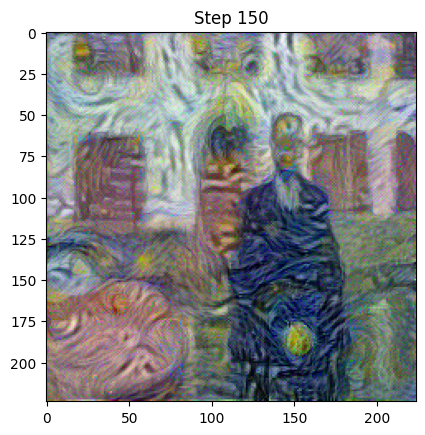

Step 200: Content Loss: 174.6365203857422, Style Loss: 0.0018291090382263064


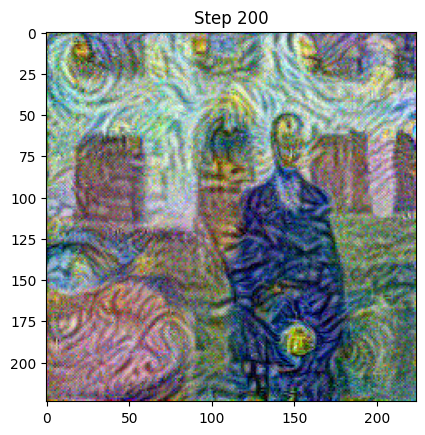

Step 250: Content Loss: 177.704833984375, Style Loss: 0.00261797197163105


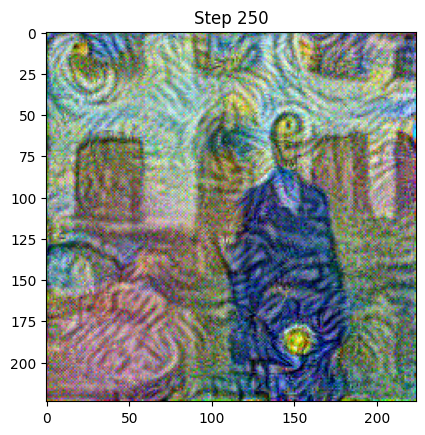

Step 300: Content Loss: 162.70550537109375, Style Loss: 0.0005737190367653966


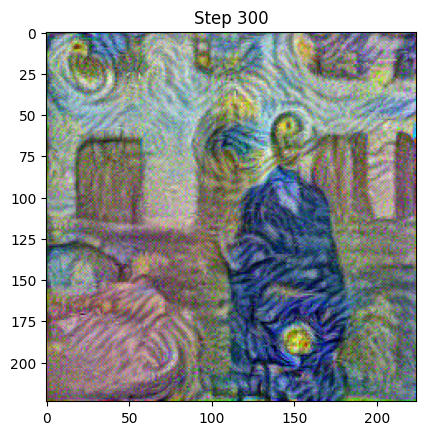

Step 350: Content Loss: 119.27049255371094, Style Loss: 6.420447607524693e-05


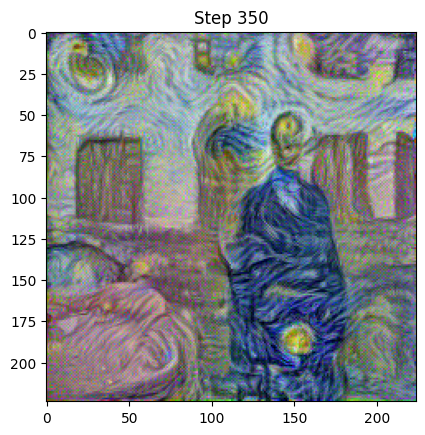

Step 400: Content Loss: 103.35765838623047, Style Loss: 5.0309557991568e-05


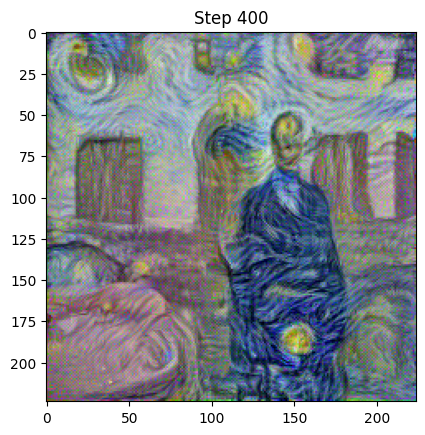

Step 450: Content Loss: 95.91145324707031, Style Loss: 4.621803236659616e-05


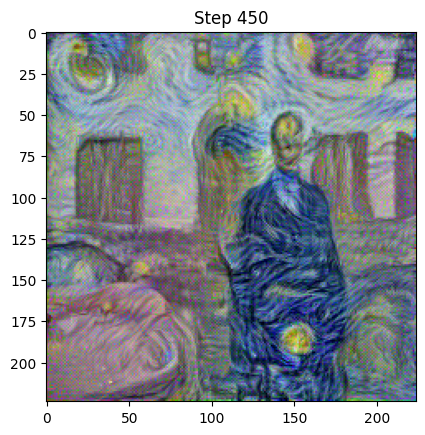

Step 500: Content Loss: 96.4419937133789, Style Loss: 4.2514249798841774e-05


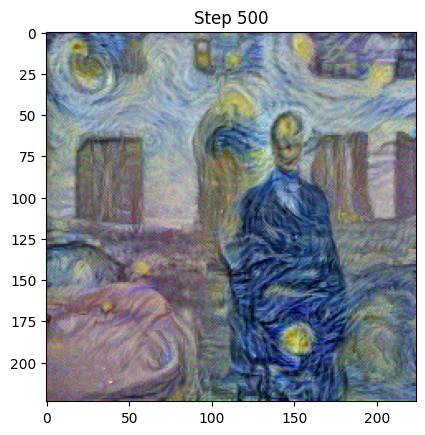

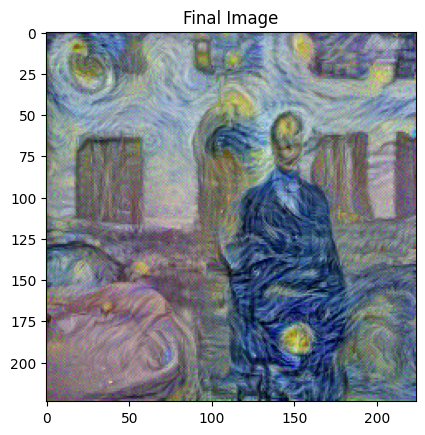

In [28]:
num_steps = 500

content_loss_history = []
style_loss_history = []
print(f"Image range: min={generated_image.min().item()}, max={generated_image.max().item()}")
display(generated_image, title="Check Step 0")

for step in range(num_steps):
  optimizer.zero_grad()

  features = vgg(generated_image)

  loss, current_c, current_s = calculate_loss(features, content_loss_modules, style_loss_modules)

  loss.backward()

  optimizer.step()

  torch.clamp_(generated_image.data, 0, 1)

  content_loss_history.append(current_c)
  style_loss_history.append(current_s)

  if (step+1) % 50 == 0 or step == 0:
    print(f"Step {step+1}: Content Loss: {current_c}, Style Loss: {current_s}")
    display(generated_image, title=f"Step {step+1}")

display(generated_image, title="Final Image")

Plot your content and style losses. Content loss should start at 0 and increase as style loss decreases. They should both reach an equilibrium.

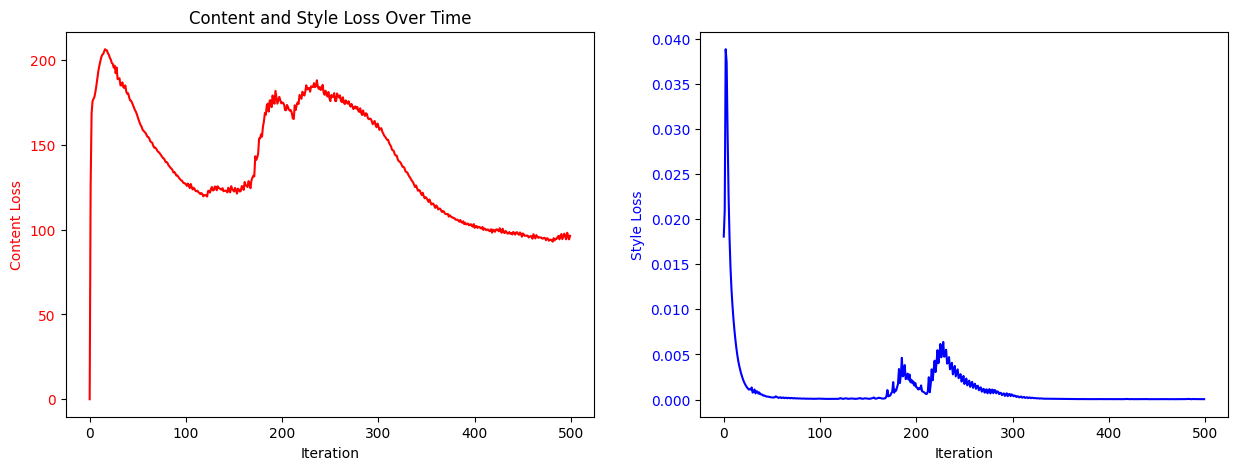

In [37]:
def plot_losses(content_loss_history, style_loss_history):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

  #Plot 1
  ax1.plot(content_loss_history, color="red", label="Content Loss")
  ax1.set_ylabel("Content Loss", color="red")
  ax1.set_xlabel("Iteration")
  ax1.set_title("Content and Style Loss Over Time")
  ax1.tick_params(axis='y', labelcolor="red")

  #Plot 2
  ax2.plot(style_loss_history, color="blue", label="Style Loss")
  ax2.set_ylabel("Style Loss", color="blue")
  ax2.set_xlabel("Iteration")
  ax2.tick_params(axis='y', labelcolor="blue")

plot_losses(content_loss_history, style_loss_history)

Now that you have style transfer working, the results may not look very appealing. Different content and style images require different hyperparameters, so you should play around with different network layers, learning rates, and loss weighting to get the best results.